# 03 — Cálculo del CLTV por cliente

Fórmula:

$$ CLTV = Ingresos_t \times Margen_t \times Frecuencia_t \times R_t $$

Donde, sobre la ventana temporal *t*:
- **Ingresos_t** = ventas netas (subtotal − devoluciones).
- **Margen_t** = (Ingresos − Coste) / Ingresos.
- **Frecuencia_t** = nº de tickets distintos.
- **R_t** = retención = meses_activos / meses_de_la_ventana.

## 0. Setup

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.analytics import compute_cltv

In [2]:
ROOT = Path('..')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
PALETTE = sns.color_palette('crest', as_cmap=False)

## 1. Cálculo

Llama al SQL en `src.analytics.cltv` y devuelve un DataFrame por cliente.

In [3]:
%%sql
with ventas as (
    select  f.customer_sk,
            sum(f.subtotal)                                 as gross_revenue,
            sum(f.subtotal - coalesce(r.returned_value,0))  as net_revenue,
            sum(f.cost)                                     as total_cost,
            count(distinct f.sale_id)                       as frequency,
            min(d.full_date)                                as first_purchase,
            max(d.full_date)                                as last_purchase,
            count(distinct date_trunc('month', d.full_date))::int as active_months
    from dwh.fact_sales f
    join dwh.dim_date d on d.date_id = f.sale_date_id
    left join (
        select sale_item_id, sum(returned_value) as returned_value
        from dwh.fact_returns
        group by sale_item_id
    ) r on r.sale_item_id = f.sale_item_id
    group by f.customer_sk
),
ventana as (
    select min(full_date) as ts, max(full_date) as te from dwh.dim_date d
    where exists (select 1 from dwh.fact_sales f where f.sale_date_id = d.date_id)
)
select  c.customer_sk,
        c.customer_id,
        c.full_name,
        v.gross_revenue,
        v.net_revenue,
        v.total_cost,
        case when v.net_revenue > 0
             then (v.net_revenue - v.total_cost) / v.net_revenue
             else 0 end                                       as margin_rate,
        v.frequency,
        v.first_purchase,
        v.last_purchase,
        v.active_months,
        (extract(year from age(w.te, w.ts)) * 12
         + extract(month from age(w.te, w.ts)) + 1)::int      as window_months,
        v.active_months::numeric
            / nullif((extract(year from age(w.te, w.ts)) * 12
                      + extract(month from age(w.te, w.ts)) + 1), 0) as retention_rate
from ventas v
join dwh.dim_customer c on c.customer_sk = v.customer_sk
cross join ventana w

,customer_sk,customer_id,full_name,gross_revenue,net_revenue,total_cost,margin_rate,frequency,first_purchase,last_purchase,active_months,window_months,retention_rate
0,1,1,Marta Ruiz García,11740.55,11510.66,7044.07,0.388039,22,2020-06-29,2025-10-01,18,72,0.250000
1,2,2,Alejandro López López,12744.26,12429.59,7646.18,0.384841,24,2020-03-02,2025-10-30,20,72,0.277778
2,3,3,Alejandro López Álvarez,19862.51,19416.56,11905.08,0.386859,24,2020-08-17,2025-11-07,19,72,0.263889
3,4,4,Javier Ruiz Fernández,8203.76,7993.78,4886.07,0.388766,10,2020-04-19,2025-12-12,10,72,0.138889
4,5,5,David Gómez Pérez,10938.05,10578.18,6526.60,0.383013,22,2020-03-17,2025-12-07,18,72,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5745,5746,5748,Guadalupe Almeida Ballester,34.99,34.99,20.99,0.400114,1,2023-08-03,2023-08-03,1,72,0.013889
5746,5747,5749,Gaspar Alcaraz Chacón,59.99,0.00,35.99,0.000000,1,2022-04-12,2022-04-12,1,72,0.013889
5747,5748,5750,Eneko Bermúdez Caparrós,139.99,139.99,83.99,0.400029,1,2025-09-08,2025-09-08,1,72,0.013889
5748,5749,5751,Hélder Andrade Carrillo,1199.97,1199.97,719.97,0.400010,1,2023-07-02,2023-07-02,1,72,0.013889


In [4]:
cltv = compute_cltv(df_CLTV)
print('clientes con CLTV calculado:', len(cltv))
cltv.head()

clientes con CLTV calculado: 5750


,customer_sk,customer_id,full_name,gross_revenue,net_revenue,total_cost,margin_rate,frequency,first_purchase,last_purchase,active_months,window_months,retention_rate,cltv
0,213,212,Sergio Álvarez Martínez,21281.51,20781.53,12768.43,0.385588,34,2020-01-20,2025-08-05,29,72,0.402778,109734.952778
1,184,183,Alejandro Pérez Pérez,24922.00,23932.15,14916.63,0.376712,33,2020-01-05,2025-10-18,26,72,0.361111,107434.946667
2,229,228,Carlos García López,22268.34,22148.45,13360.50,0.396775,30,2020-01-12,2025-12-22,27,72,0.375000,98864.437500
3,344,343,Alejandro Fernández Pérez,21167.80,20682.93,12676.26,0.387115,30,2020-07-18,2025-11-14,27,72,0.375000,90075.037500
4,503,500,Sergio Martínez Gómez,19215.39,19035.50,11516.76,0.394985,32,2020-03-30,2025-10-19,26,72,0.361111,86883.217778


## 2. Estadística descriptiva

Métricas clave del CLTV y de sus componentes.

In [5]:
desc = cltv[['gross_revenue','net_revenue','margin_rate','frequency',
             'retention_rate','cltv']].describe().round(2)
desc

,gross_revenue,net_revenue,margin_rate,frequency,retention_rate,cltv
count,5750.00,5750.00,5750.00,5750.00,5750.00,5750.00
mean,1683.26,1635.20,0.36,3.48,0.04,3165.48
std,4090.00,3989.09,0.13,6.59,0.08,9929.97
min,19.99,-179.99,-0.80,1.00,0.01,-1.11
25%,79.80,59.99,0.40,1.00,0.01,0.29
50%,149.90,129.99,0.40,1.00,0.01,0.72
75%,299.99,299.99,0.40,1.00,0.01,1.67
max,24922.00,23932.15,1.00,34.00,0.40,109734.95


## 3. Distribución del CLTV

### 3.1. Concentración de valor — Lorenz

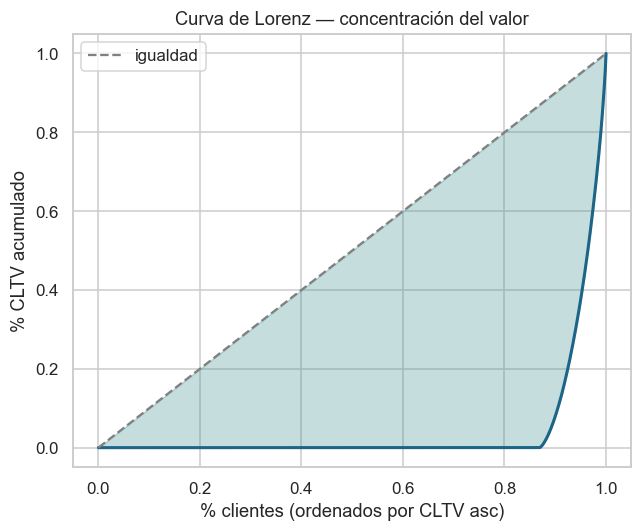

El top 20% de clientes concentra el 100.0% del CLTV total


In [6]:
vals = np.sort(cltv['cltv'].clip(lower=0).values)
cum = np.cumsum(vals) / vals.sum() if vals.sum() > 0 else np.zeros_like(vals)
share = np.arange(1, len(vals)+1) / len(vals)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(share, cum, color=PALETTE[4], lw=2)
ax.plot([0,1],[0,1], ls='--', color='gray', label='igualdad')
ax.fill_between(share, share, cum, color=PALETTE[2], alpha=0.3)
ax.set_xlabel('% clientes (ordenados por CLTV asc)')
ax.set_ylabel('% CLTV acumulado')
ax.set_title('Curva de Lorenz — concentración del valor')
ax.legend()
plt.tight_layout()
plt.show()

top20 = cltv['cltv'].nlargest(int(len(cltv)*0.2)).sum() / cltv['cltv'].sum() * 100
print(f'El top 20% de clientes concentra el {top20:.1f}% del CLTV total')

## 4. Top de clientes

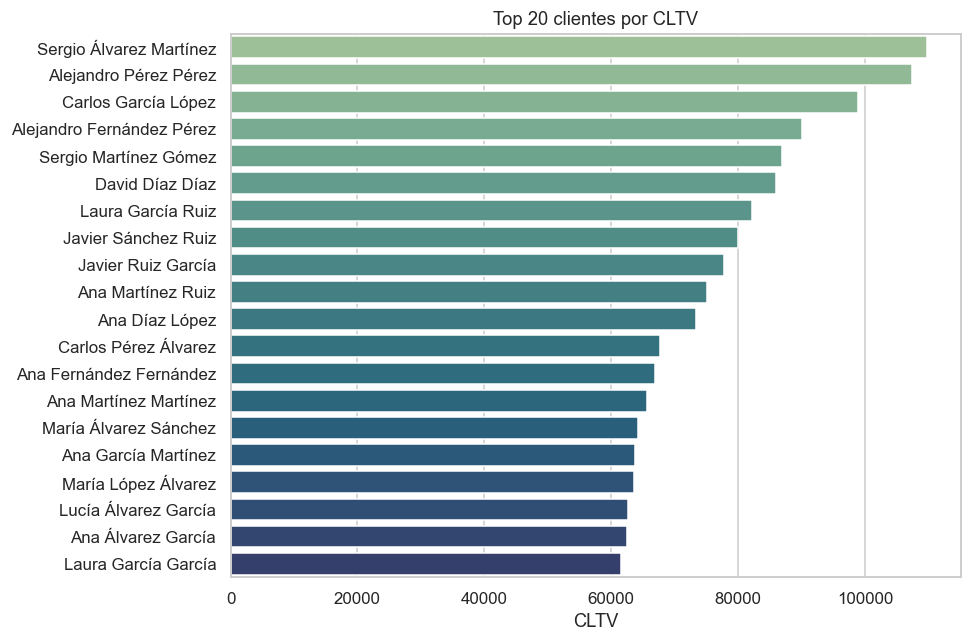

,full_name,cltv,net_revenue,frequency,margin_rate
0,Sergio Álvarez Martínez,109734.952778,20781.53,34,0.385588
1,Alejandro Pérez Pérez,107434.946667,23932.15,33,0.376712
2,Carlos García López,98864.437500,22148.45,30,0.396775
3,Alejandro Fernández Pérez,90075.037500,20682.93,30,0.387115
4,Sergio Martínez Gómez,86883.217778,19035.50,32,0.394985
5,David Díaz Díaz,86031.027778,20925.08,31,0.381961
6,Laura García Ruiz,82156.923333,19201.55,31,0.382213
7,Javier Sánchez Ruiz,80014.472222,21038.75,28,0.391186
8,Javier Ruiz García,77761.381389,19312.32,29,0.384495
9,Ana Martínez Ruiz,75126.024306,17957.47,31,0.388666


In [7]:
top = cltv.nlargest(20, 'cltv')[['full_name','cltv','net_revenue','frequency','margin_rate']]
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top, y='full_name', x='cltv', hue='full_name',
            palette='crest', ax=ax, legend=False)
ax.set_xlabel('CLTV')
ax.set_ylabel('')
ax.set_title('Top 20 clientes por CLTV')
plt.tight_layout()
plt.show()

top

## 5. Componentes del CLTV

Vemos cómo se relacionan los factores que multiplican.

### 5.1. Distribución de cada componente

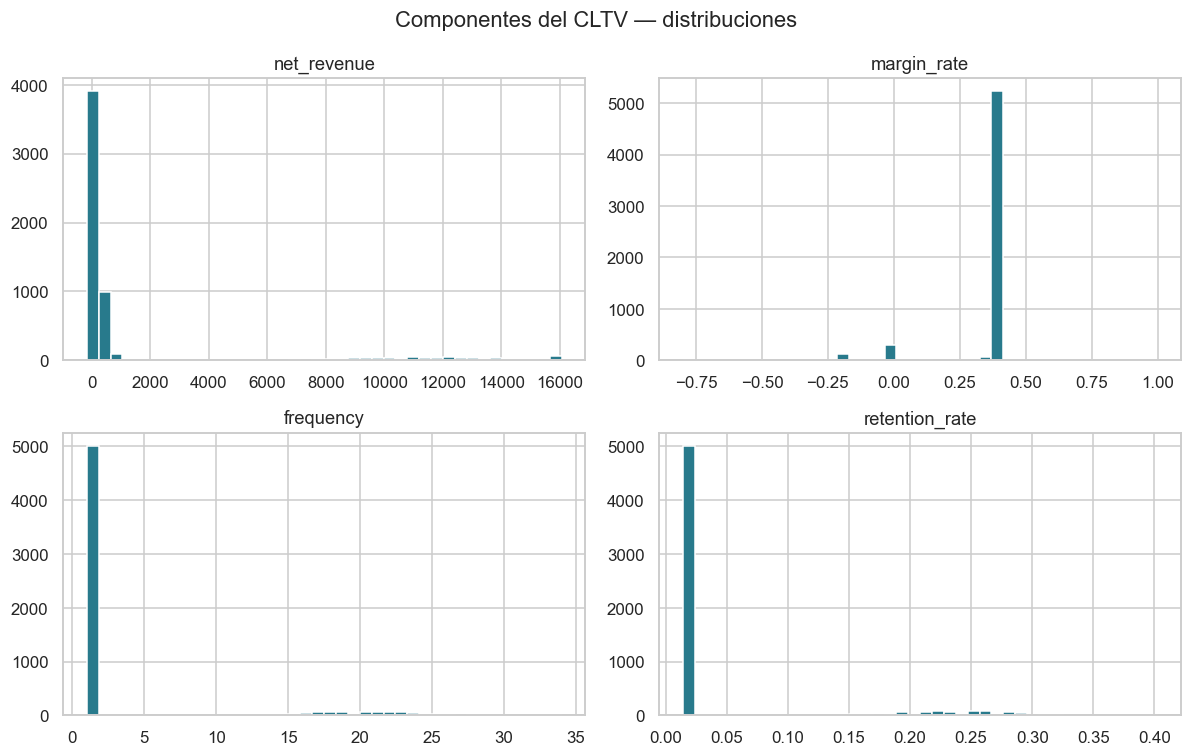

In [8]:
comps = ['net_revenue','margin_rate','frequency','retention_rate']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.flatten(), comps):
    s = cltv[c].astype(float)
    s = s.clip(upper=s.quantile(0.99)) if c == 'net_revenue' else s
    ax.hist(s.dropna(), bins=40, color=PALETTE[3], edgecolor='white')
    ax.set_title(c)
plt.suptitle('Componentes del CLTV — distribuciones')
plt.tight_layout()
plt.show()

### 5.2. Correlaciones entre componentes y CLTV

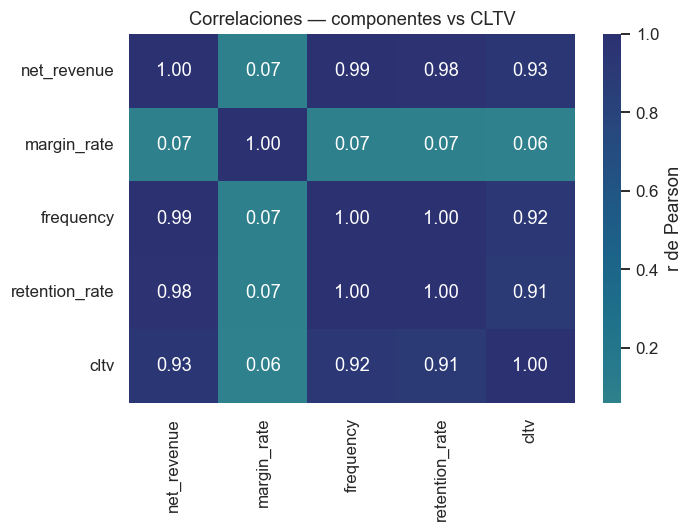

In [9]:
corr = cltv[['net_revenue','margin_rate','frequency','retention_rate','cltv']].corr().round(2)
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='crest', center=0, ax=ax,
            cbar_kws={'label':'r de Pearson'})
ax.set_title('Correlaciones — componentes vs CLTV')
plt.tight_layout()
plt.show()

## 6. Persistencia

In [10]:
out = ROOT / 'data' / 'processed' / 'cltv.parquet'
out.parent.mkdir(parents=True, exist_ok=True)
cltv.to_parquet(out, index=False)
out

PosixPath('../data/processed/cltv.parquet')